In [3]:
#importing the libraries and dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [4]:
# Loading the dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/time_series_60min_singleindex.csv')

Mounted at /content/drive


In [5]:
print(df.shape)

(50401, 300)


In [6]:
#first 5 rows
print(df.head())

          utc_timestamp        cet_cest_timestamp  \
0  2014-12-31T23:00:00Z  2015-01-01T00:00:00+0100   
1  2015-01-01T00:00:00Z  2015-01-01T01:00:00+0100   
2  2015-01-01T01:00:00Z  2015-01-01T02:00:00+0100   
3  2015-01-01T02:00:00Z  2015-01-01T03:00:00+0100   
4  2015-01-01T03:00:00Z  2015-01-01T04:00:00+0100   

   AT_load_actual_entsoe_transparency  AT_load_forecast_entsoe_transparency  \
0                                 NaN                                   NaN   
1                              5946.0                                6701.0   
2                              5726.0                                6593.0   
3                              5347.0                                6482.0   
4                              5249.0                                6454.0   

   AT_price_day_ahead  AT_solar_generation_actual  \
0                 NaN                         NaN   
1                35.0                         NaN   
2                45.0                         N

In [7]:
print("Columns:")
print(df.columns)

Columns:
Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       ...
       'SI_load_actual_entsoe_transparency',
       'SI_load_forecast_entsoe_transparency', 'SI_solar_generation_actual',
       'SI_wind_onshore_generation_actual',
       'SK_load_actual_entsoe_transparency',
       'SK_load_forecast_entsoe_transparency', 'SK_solar_generation_actual',
       'SK_wind_onshore_generation_actual',
       'UA_load_actual_entsoe_transparency',
       'UA_load_forecast_entsoe_transparency'],
      dtype='object', length=300)


In [8]:
print("Data types:")
print(df.dtypes)

Data types:
utc_timestamp                            object
cet_cest_timestamp                       object
AT_load_actual_entsoe_transparency      float64
AT_load_forecast_entsoe_transparency    float64
AT_price_day_ahead                      float64
                                         ...   
SK_load_forecast_entsoe_transparency    float64
SK_solar_generation_actual              float64
SK_wind_onshore_generation_actual       float64
UA_load_actual_entsoe_transparency      float64
UA_load_forecast_entsoe_transparency    float64
Length: 300, dtype: object


In [9]:
# Converting timestamp column
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"],utc="Ture")

# Keeping only Germany Ele load data
df = df[["utc_timestamp", "DE_load_actual_entsoe_transparency"]]

df.rename(columns={"DE_load_actual_entsoe_transparency":"DE_Load"}, inplace=True)


In [10]:
#checking whether there are any missing values or not
print("Missing values:")
print(df.isnull().sum())

Missing values:
utc_timestamp    0
DE_Load          1
dtype: int64


In [11]:
df = df.dropna(subset=["DE_Load"])

In [ ]:
print(df.head())

              utc_timestamp  DE_Load
1 2015-01-01 00:00:00+00:00  41151.0
2 2015-01-01 01:00:00+00:00  40135.0
3 2015-01-01 02:00:00+00:00  39106.0
4 2015-01-01 03:00:00+00:00  38765.0
5 2015-01-01 04:00:00+00:00  38941.0


In [12]:
#Keep only values from January 1st 2015 until the end of the file, October 2020
df = df[
    (df["utc_timestamp"]>= "2015-01-01") &
    (df["utc_timestamp"]<= "2020-09-30 23:00:00")
]

In [13]:
print(df.shape)

(50400, 2)


In [14]:
df.set_index("utc_timestamp", inplace=True)

In [15]:
#Converting Hourly Data to Daily and Weekly
daily = df.resample("D").mean()
weekly = df.resample("W").mean()


In [16]:
#checking final dataframe
df.head()


,DE_Load
utc_timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


In [17]:
print(df.tail())

                           DE_Load
utc_timestamp                     
2020-09-30 19:00:00+00:00  57559.0
2020-09-30 20:00:00+00:00  54108.0
2020-09-30 21:00:00+00:00  49845.0
2020-09-30 22:00:00+00:00  46886.0
2020-09-30 23:00:00+00:00  45461.0


In [18]:
print("Index type:", type(df.index))
print("Date range:", df.index.min(), "to", df.index.max())
print("Shape:", df.shape)

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Date range: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Shape: (50400, 1)


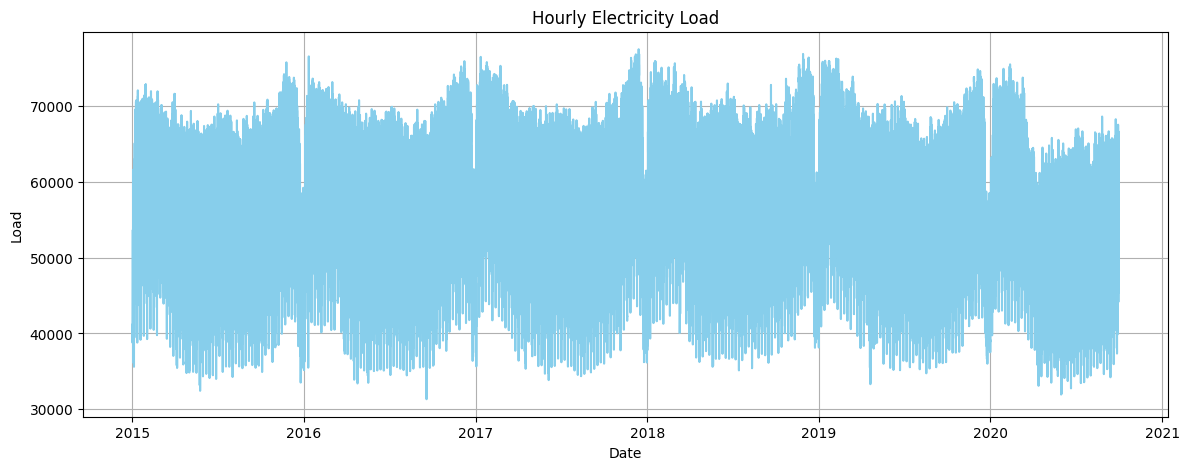

In [19]:
# Initial visualization of the time series
plt.figure(figsize=(14,5))
plt.plot(df["DE_Load"],color="skyblue")
plt.title("Hourly Electricity Load")
plt.xlabel("Date")
plt.ylabel("Load")
plt.grid(True)
plt.savefig("Figure1-Hourly.png", dpi=300, bbox_inches="tight")
plt.show()

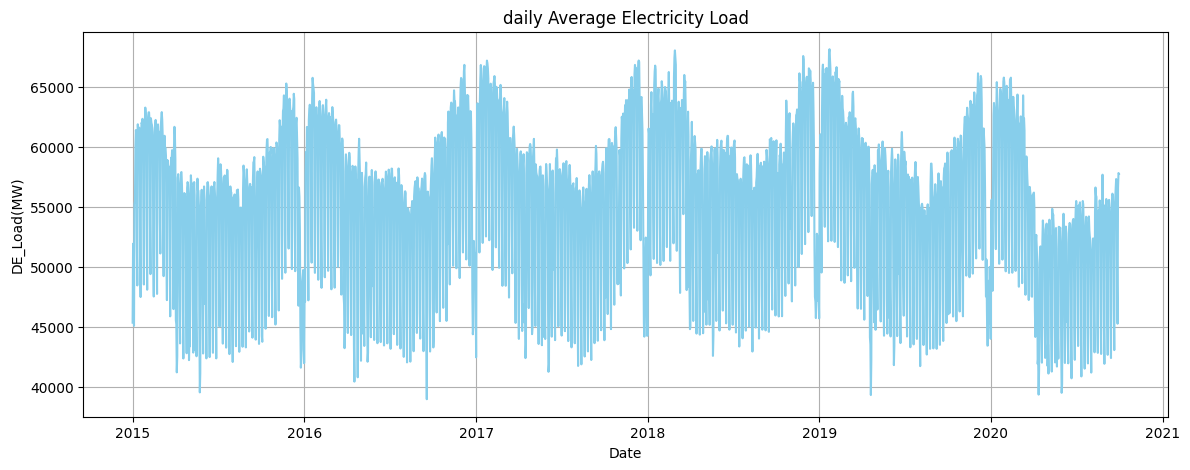

In [20]:
plt.figure(figsize=(14,5))
plt.plot(daily["DE_Load"],color="skyblue")
plt.title("daily Average Electricity Load")
plt.xlabel("Date")
plt.ylabel("DE_Load(MW)")
plt.grid(True)
plt.savefig("Figure2-Daily.png", dpi=300, bbox_inches="tight")
plt.show()

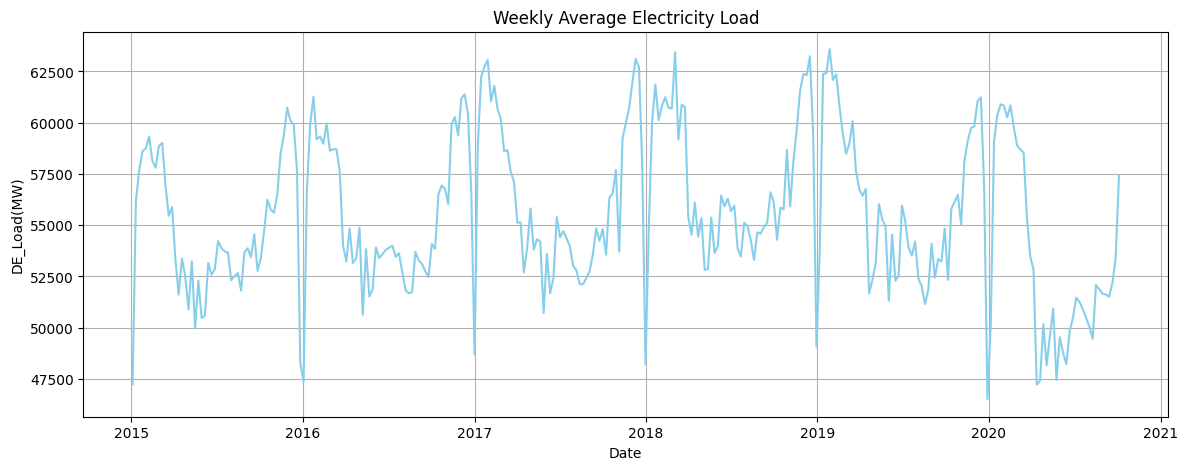

In [21]:
plt.figure(figsize=(14,5))
plt.plot(weekly["DE_Load"],color="skyblue")
plt.title("Weekly Average Electricity Load")
plt.xlabel("Date")
plt.ylabel("DE_Load(MW)")
plt.grid(True)
plt.savefig("Figure3-weekly.png", dpi=300, bbox_inches="tight")
plt.show()

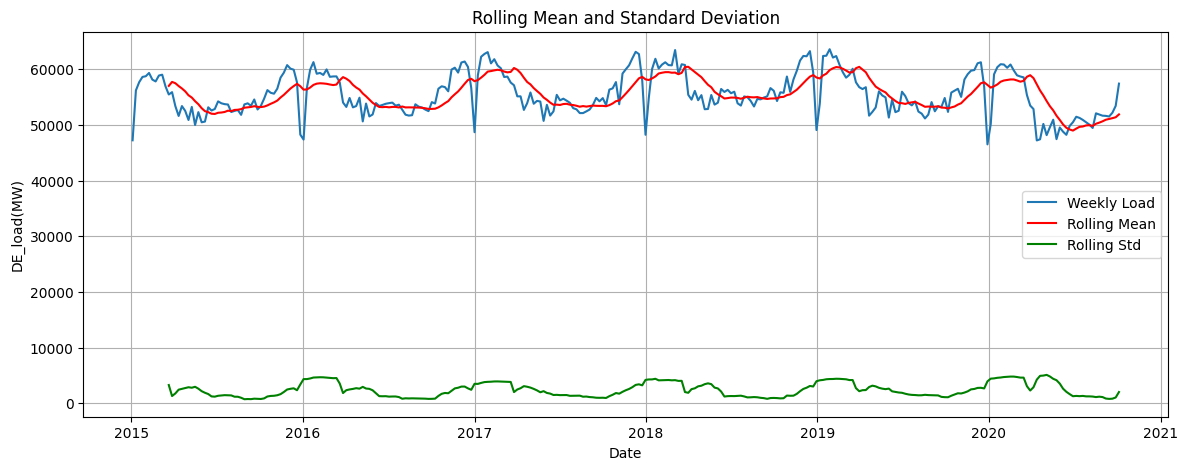

In [22]:
#calculating rolling mean and std
rolling_mean = weekly["DE_Load"].rolling(12).mean()
rolling_std = weekly["DE_Load"].rolling(window=12).std()

plt.figure(figsize=(14,5))
plt.plot(weekly["DE_Load"], label="Weekly Load")
plt.plot(rolling_mean, color="red", label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std", color="green")

plt.title("Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("DE_load(MW)")
plt.legend()
plt.grid(True)
plt.savefig("Figure4-Rolling.png", dpi=300, bbox_inches="tight")
plt.show()

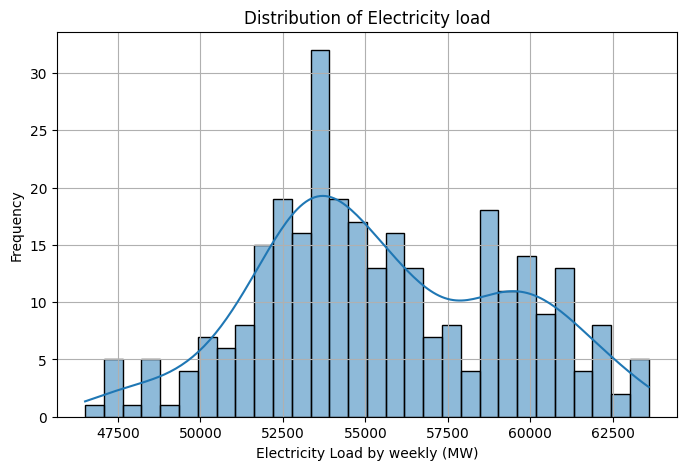

In [23]:
# Distribution of electricity load
plt.figure(figsize=(8,5))
sns.histplot(weekly["DE_Load"], bins=30, kde=True)
plt.title("Distribution of Electricity load")
plt.xlabel("Electricity Load by weekly (MW)")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("Figure5-Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

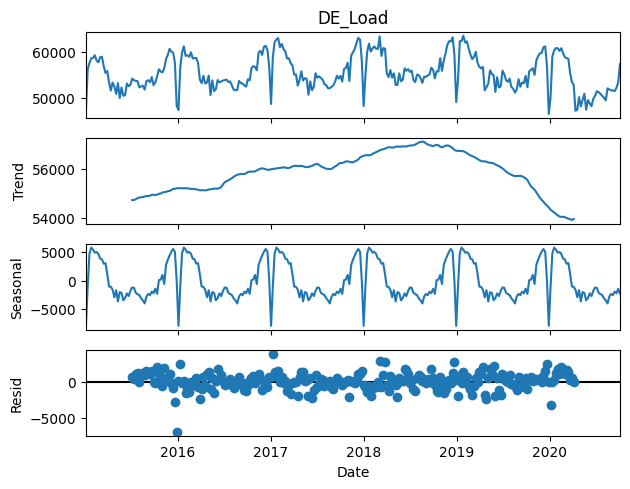

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    weekly["DE_Load"],
    model="additive",
    period=52
)

decomposition.plot()
plt.xlabel("Date")
plt.savefig("Figure6-Decomposition.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
#checking whether it is stationary or not
result = adfuller(weekly["DE_Load"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("\nCritical Values:")
for key, value in result[4].items():
  print(f"{key}: {value}")
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

ADF Statistic: -4.0474718556784826
p-value: 0.0011813497340154512

Critical Values:
1%: -3.4529449243622383
5%: -2.871489553425686
10%: -2.572071437887033
The series is stationary.


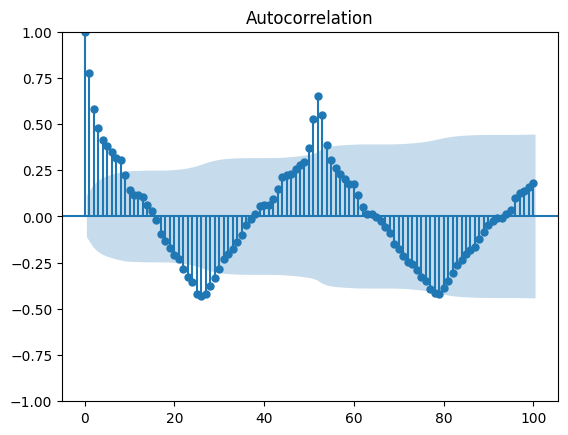

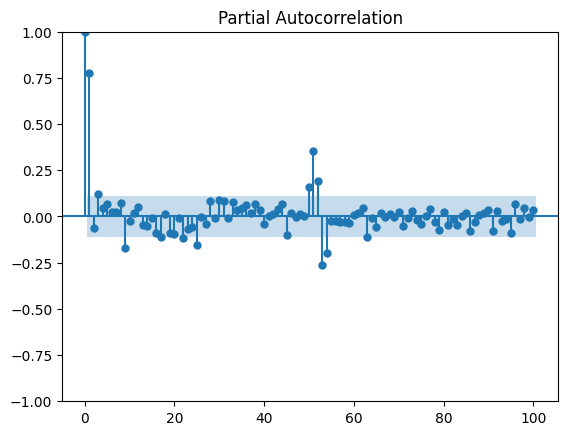

In [26]:
#acf and pacf
plot_acf(weekly["DE_Load"], lags=100)
plt.savefig("Figure7-acf.png", dpi=300, bbox_inches="tight")
plt.show()
plot_pacf(weekly["DE_Load"], lags=100)
plt.savefig("Figure8-pacf.png", dpi=300, bbox_inches="tight")
plt.show()

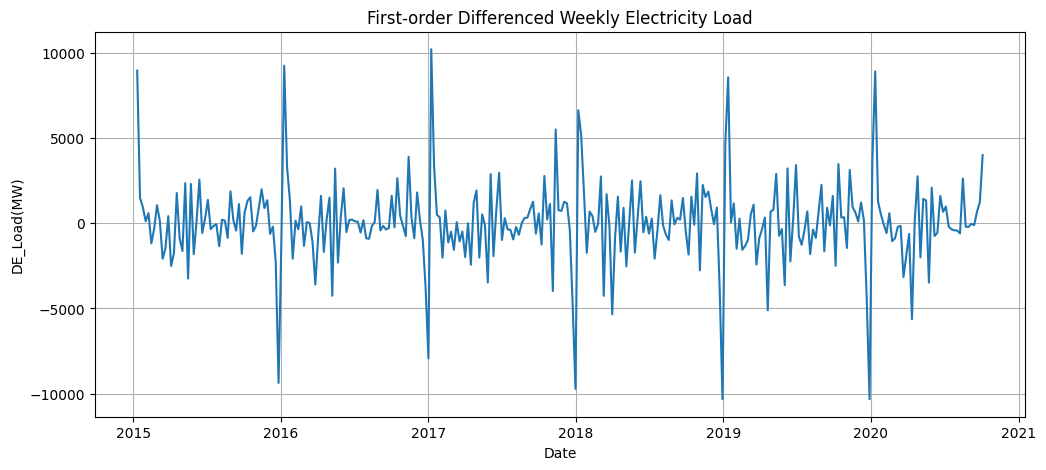

ADF Statistic: -7.069318170017982
p-value: 4.984737279649353e-10


In [27]:
weekly_diff = weekly["DE_Load"].diff().dropna()
plt.figure(figsize=(12,5))
plt.plot(weekly_diff)
plt.title("First-order Differenced Weekly Electricity Load")
plt.xlabel("Date")
plt.ylabel("DE_Load(MW)")
plt.grid(True)
plt.savefig("Figure9-diff.png", dpi=300, bbox_inches="tight")
plt.show()
result_diff = adfuller(weekly_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

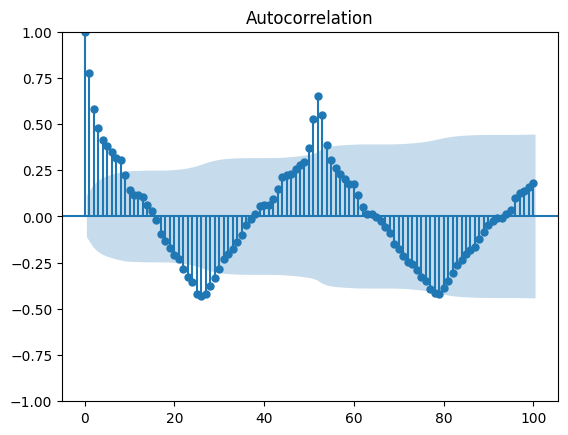

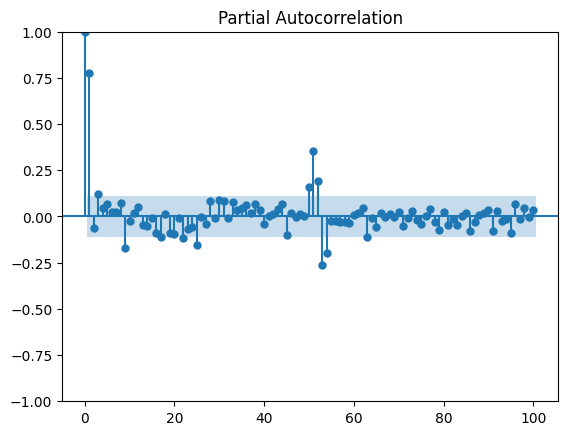

In [28]:
#acf and pacf
plot_acf(weekly["DE_Load"], lags=100)
plt.savefig("Figure10-acf.png", dpi=300, bbox_inches="tight")
plt.show()
plot_pacf(weekly["DE_Load"], lags=100)
plt.show()

In [29]:
# part 2 Benchmark models
train = weekly.iloc[:-104]
test = weekly.iloc[-104:]

In [30]:
horizon = len(test)
season_length = 52
def mean_forecast(history, horizon):
    return np.repeat(history.mean(), horizon)
def naive_forecast(history, horizon):
    return np.repeat(history.iloc[-1], horizon)
def seasonal_naive_forecast(history, horizon, season_length):

    forecast = []

    for i in range(horizon):
        forecast.append(history.iloc[-season_length + (i % season_length)])

    return np.array(forecast)
def drift_forecast(history, horizon):

    first = history.iloc[0]
    last = history.iloc[-1]

    slope = (last - first) / (len(history) - 1)

    forecast = []

    for h in range(1, horizon + 1):
        forecast.append(last + h * slope)

    return np.array(forecast)
mean_pred = mean_forecast(train["DE_Load"], horizon)

naive_pred = naive_forecast(train["DE_Load"], horizon)

seasonal_pred = seasonal_naive_forecast(
    train["DE_Load"],
    horizon,
    season_length
)

drift_pred = drift_forecast(train["DE_Load"], horizon)

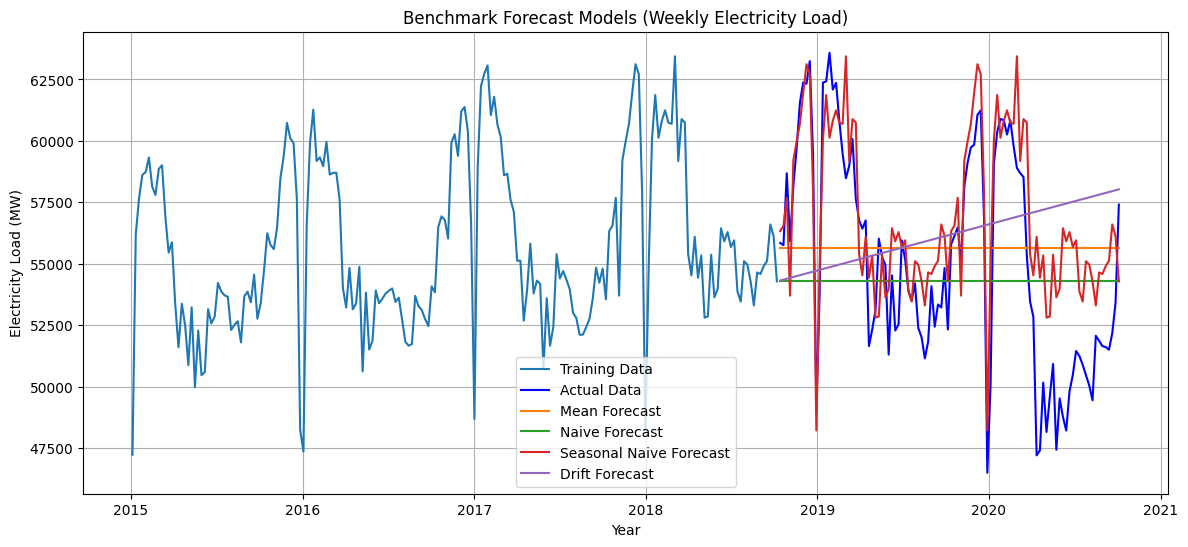

In [31]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["DE_Load"], label="Training Data")

plt.plot(test.index, test["DE_Load"], label="Actual Data", color="blue")

plt.plot(test.index, mean_pred, label="Mean Forecast")

plt.plot(test.index, naive_pred, label="Naive Forecast")

plt.plot(test.index, seasonal_pred, label="Seasonal Naive Forecast")

plt.plot(test.index, drift_pred, label="Drift Forecast")

plt.title("Benchmark Forecast Models (Weekly Electricity Load)")
plt.xlabel("Year")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)
plt.savefig("Figure11-Benchmark.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
import warnings
warnings.filterwarnings("ignore")
from itertools import product
import pandas as pd
import statsmodels.api as sm
from tqdm import tqdm

# Training and testing data
train = weekly.iloc[:-104]
test = weekly.iloc[-104:]

def optimize_sarima(load_data, order_list):

    results = []

    for order in tqdm(order_list):

        try:
            model = sm.tsa.statespace.SARIMAX(
                load_data,
                order=order,
                seasonal_order=(1,1,1,52)
            )

            model_fit = model.fit(disp=False)

            results.append([order, model_fit.aic])

        except:
            continue

    results_df = pd.DataFrame(
        results,
        columns=["(p,d,q)", "AIC"]
    )

    results_df = results_df.sort_values(
        by="AIC",
        ascending=True
    ).reset_index(drop=True)

    return results_df

#combinations
p = range(0,7)
d = range(0,3)
q = range(0,7)

order_list = list(product(p,d,q))
results = optimize_sarima(train["DE_Load"], order_list)

print(results.head())

100%|██████████| 147/147 [2:59:31<00:00, 73.28s/it] 

     (p,d,q)          AIC
0  (1, 0, 0)  2569.460004
1  (2, 0, 0)  2571.085763
2  (0, 0, 3)  2572.693421
3  (3, 0, 0)  2572.730520
4  (1, 0, 2)  2573.204289


In [33]:
# Best parameters
best_order = results.iloc[0]["(p,d,q)"]

print("Best Order :", best_order)

sarima_model = sm.tsa.statespace.SARIMAX(
    train["DE_Load"],
    order=best_order,
    seasonal_order=(1,1,1,52)
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

Best Order : (1, 0, 0)
                                      SARIMAX Results                                       
Dep. Variable:                              DE_Load   No. Observations:                  197
Model:             SARIMAX(1, 0, 0)x(1, 1, [1], 52)   Log Likelihood               -1280.730
Date:                              Wed, 15 Jul 2026   AIC                           2569.460
Time:                                      23:56:34   BIC                           2581.367
Sample:                                  01-04-2015   HQIC                          2574.298
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0471      0.033      1.432      0.152      -0.017       0.

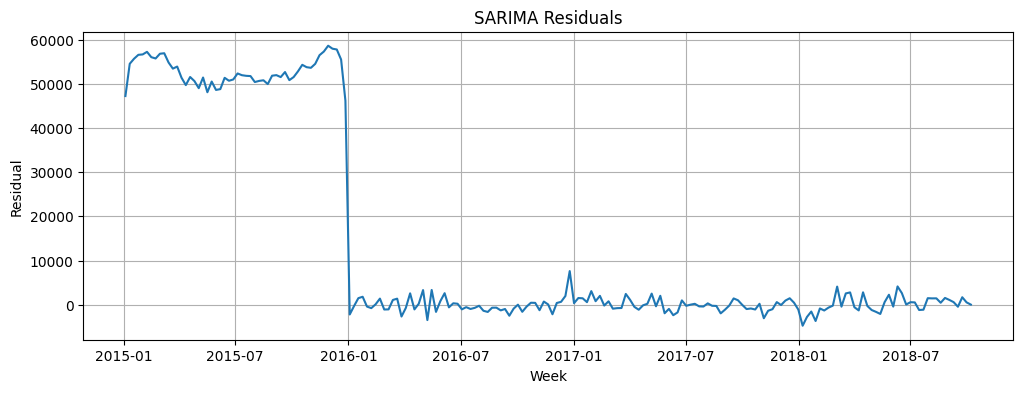

In [34]:
# Residuals
residuals = sarima_fit.resid
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("SARIMA Residuals")
plt.xlabel("Week")
plt.ylabel("Residual")
plt.grid(True)
plt.savefig("Figure12-Residuals.png", dpi=300, bbox_inches="tight")
plt.show()


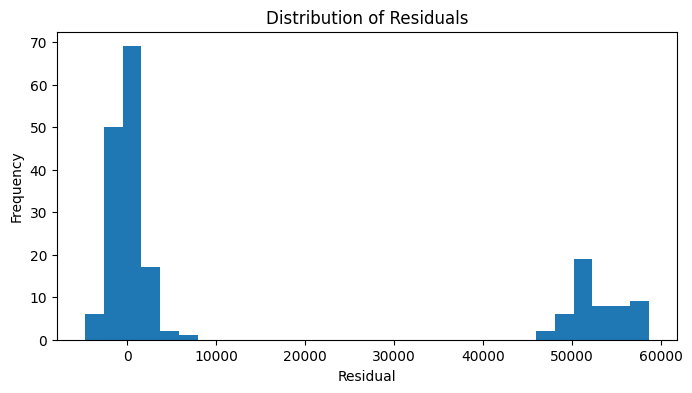

In [35]:
# Histogram
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.savefig("Figure13-Histogram.png", dpi=300, bbox_inches="tight")
plt.show()

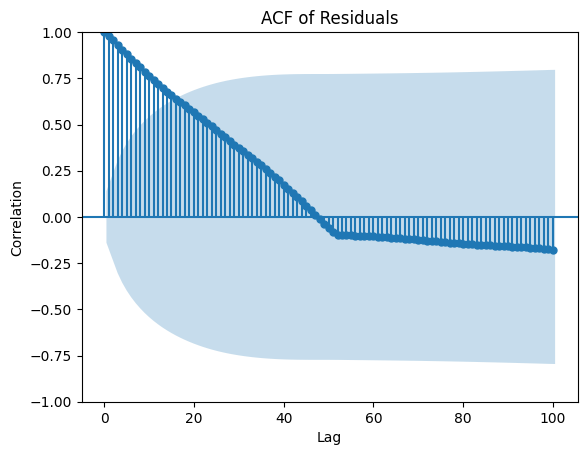

In [36]:
# ACF plot
plot_acf(residuals, lags=100)
plt.title("ACF of Residuals")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.savefig("Figure14-ACF.png", dpi=300, bbox_inches="tight")
plt.show()

RMSE : 3863.46


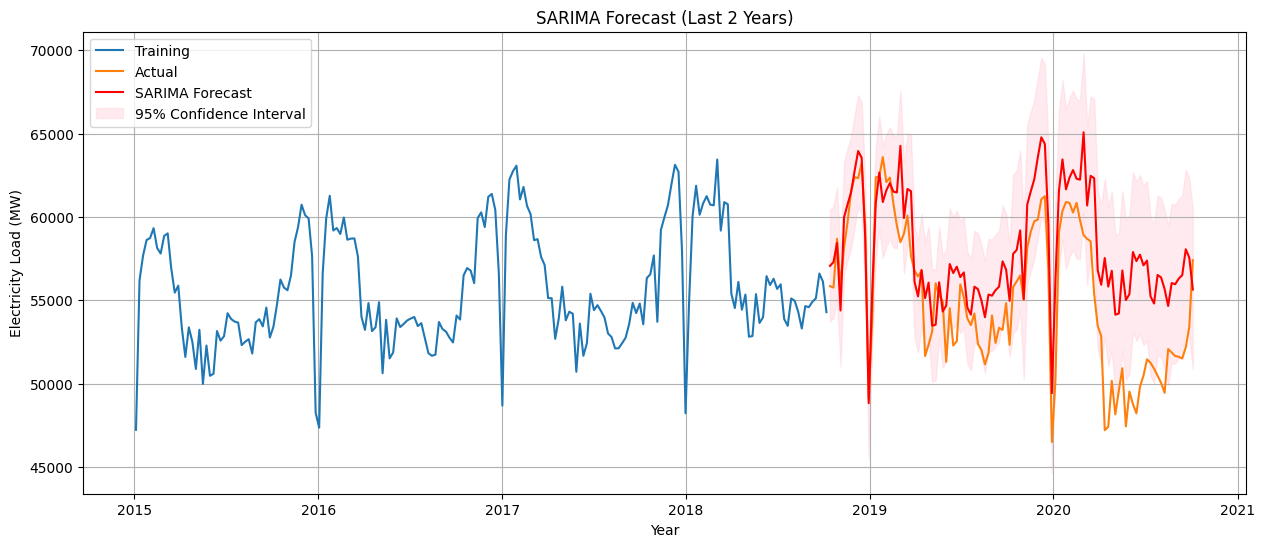

In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Forecasting 104 weeks
forecast = sarima_fit.get_forecast(steps=104)
forecast_mean = forecast.predicted_mean

confidence = forecast.conf_int()
rmse = np.sqrt(
    mean_squared_error(
        test["DE_Load"],
        forecast_mean
    )
)

print("RMSE :", round(rmse,2))
plt.figure(figsize=(15,6))

plt.plot(train.index,
         train["DE_Load"],
         label="Training")

plt.plot(test.index,
         test["DE_Load"],
         label="Actual")

plt.plot(test.index,
         forecast_mean,
         color="red",
         label="SARIMA Forecast")

plt.fill_between(
    test.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast (Last 2 Years)")
plt.xlabel("Year")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
#part4
import requests
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 52.52,
    "longitude": 13.41,
    "start_date": "2015-01-01",
    "end_date": "2020-09-30",
    "daily": "temperature_2m_mean",
    "timezone": "Europe/Berlin"
}

response = requests.get(url, params=params)
data = response.json()

temp = pd.DataFrame({
    "Date": data["daily"]["time"],
    "Temperature": data["daily"]["temperature_2m_mean"]
})

temp["Date"] = pd.to_datetime(temp["Date"])

temp.set_index("Date", inplace=True)
weekly_temp = temp.resample("W").mean()

print(weekly_temp.head())
if weekly_temp.index.tz is not None:
    weekly_temp.index = weekly_temp.index.tz_localize(None)

if weekly.index.tz is not None:
    weekly.index = weekly.index.tz_localize(None)

# Merging weekly load data  with weekly temperature
feature_df = weekly.join(weekly_temp, how="inner")
feature_df = feature_df.dropna()

print(feature_df.head())


            Temperature
Date                   
2015-01-04     3.575000
2015-01-11     3.885714
2015-01-18     4.900000
2015-01-25     0.028571
2015-02-01     1.414286
                    DE_Load  Temperature
utc_timestamp                           
2015-01-04     47233.739583     3.575000
2015-01-11     56191.101190     3.885714
2015-01-18     57672.678571     4.900000
2015-01-25     58613.303571     0.028571
2015-02-01     58734.029762     1.414286


RMSE: 3907.84


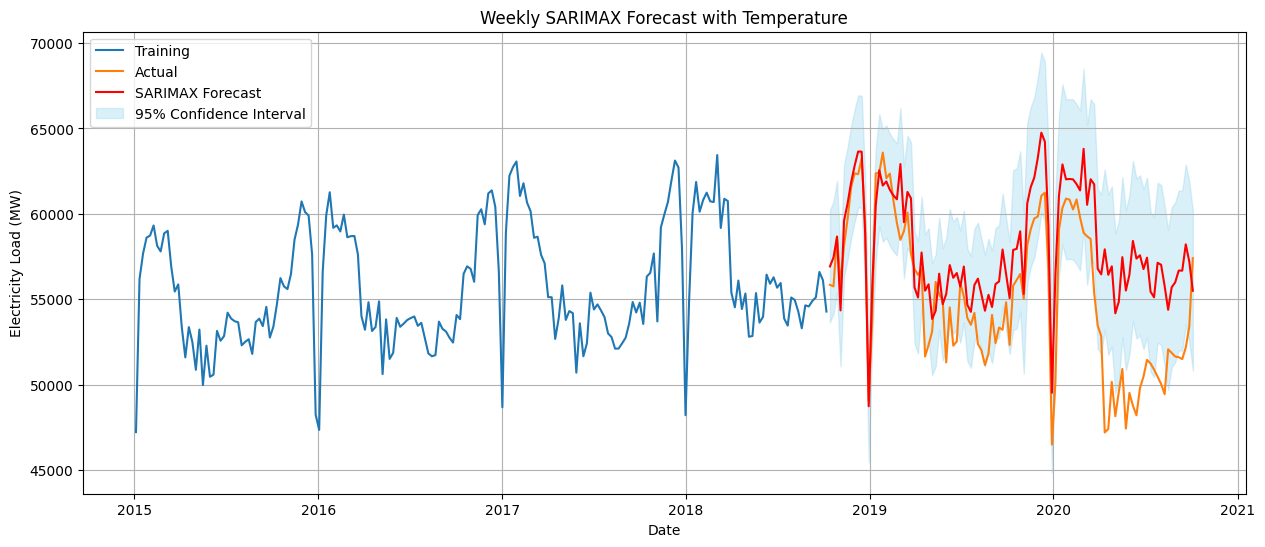

In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Target variable
y = feature_df["DE_Load"]

# Exogenous variable
X = feature_df[["Temperature"]]
test_weeks = 104

y_train = y.iloc[:-test_weeks]
y_test = y.iloc[-test_weeks:]

X_train = X.iloc[:-test_weeks]
X_test = X.iloc[-test_weeks:]

#SARIMAX model
sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=best_order,

    seasonal_order=(1,1,1,52)
)

sarimax_fit = sarimax.fit()

forecast = sarimax_fit.get_forecast(
    steps=test_weeks,
    exog=X_test
)

forecast_mean = forecast.predicted_mean

confidence = forecast.conf_int()
rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
print("RMSE:", round(rmse,2))

plt.figure(figsize=(15,6))

plt.plot(y_train.index, y_train, label="Training")

plt.plot(y_test.index, y_test, label="Actual")

plt.plot(y_test.index,
         forecast_mean,
         color="red",
         label="SARIMAX Forecast")

plt.fill_between(
    y_test.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.3,
    color="skyblue",
    label="95% Confidence Interval"
)

plt.title("Weekly SARIMAX Forecast with Temperature")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)
plt.savefig("Figure15-SARIMAX.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# Copying data from feature_df
feature_df = feature_df.sort_index()

#input and target variable
X = feature_df[["Temperature"]]
y = feature_df["DE_Load"]

print(feature_df.head())


                    DE_Load  Temperature
utc_timestamp                           
2015-01-04     47233.739583     3.575000
2015-01-11     56191.101190     3.885714
2015-01-18     57672.678571     4.900000
2015-01-25     58613.303571     0.028571
2015-02-01     58734.029762     1.414286


In [41]:
test_weeks = 104

X_train = X.iloc[:-test_weeks]
X_test = X.iloc[-test_weeks:]

y_train = y.iloc[:-test_weeks]
y_test = y.iloc[-test_weeks:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (197, 1)
Testing data: (104, 1)


In [42]:
#DEVELOPING THE MODEL
RF_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

RF_model.fit(X_train, y_train)
RF_forecast = RF_model.predict(X_test)

RMSE: 3533.48


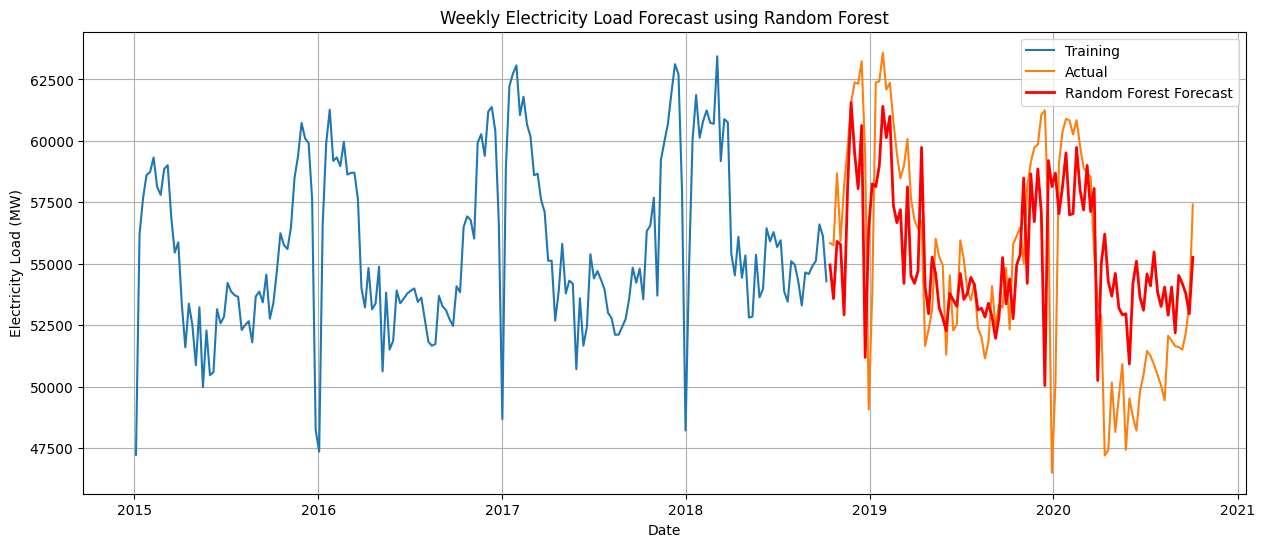

In [43]:
#CALCULATING RMSE FOR RF
rmse = np.sqrt(mean_squared_error(y_test, RF_forecast))

print("RMSE:", round(rmse,2))

plt.figure(figsize=(15,6))

plt.plot(y_train.index, y_train, label="Training")

plt.plot(y_test.index, y_test, label="Actual")

plt.plot(
    y_test.index,
    RF_forecast,
    color="red",
    linewidth=2,
    label="Random Forest Forecast"
)

plt.title("Weekly Electricity Load Forecast using Random Forest")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)
plt.savefig("Figure16-RandomForest.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
#part6
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
hourly_data = df.copy()
data = hourly_data.dropna()

print(data.head())
print(data.shape)

                           DE_Load
utc_timestamp                     
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
(50400, 1)


In [45]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_sequences(data, window):

    X = []
    y = []

    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

window = 24

X, y = create_sequences(
    scaled_data,
    window
)

print(X.shape)
print(y.shape)

(50376, 24, 1)
(50376, 1)


In [46]:
test_size = 365 * 24 * 2

X_train = X[:-test_size]
X_test = X[-test_size:]

y_train = y[:-test_size]
y_test = y[-test_size:]


print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (32856, 24, 1)
Testing: (17520, 24, 1)


In [47]:
model = Sequential()
model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.2))
model.add(
    LSTM(32)
)

model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stopping = EarlyStopping(
    patience=5,
    restore_best_weights=True
)
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - loss: 0.0227 - val_loss: 0.0058
Epoch 2/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.0076 - val_loss: 0.0025
Epoch 3/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 0.0049 - val_loss: 0.0016
Epoch 4/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 0.0037 - val_loss: 0.0012
Epoch 5/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 6/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.0024 - val_loss: 8.3992e-04
Epoch 7/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 0.0021 - val_loss: 7.5912e-04
Epoch 8/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 0.0018 - val_loss: 7.3402e-04
Epoch 9/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 10/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.0016 - val_loss: 7.4579e-04
Epoch 11/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.0015 - val_loss: 7.2521e-04
Epoch 12/2

In [48]:
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)

print(y_pred[:5])

548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
[[46211.098]
 [45119.844]
 [48831.426]
 [51155.   ]
 [58371.56 ]]


In [49]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred
    )
)
print("RMSE:", rmse)

RMSE: 1124.8056593992746


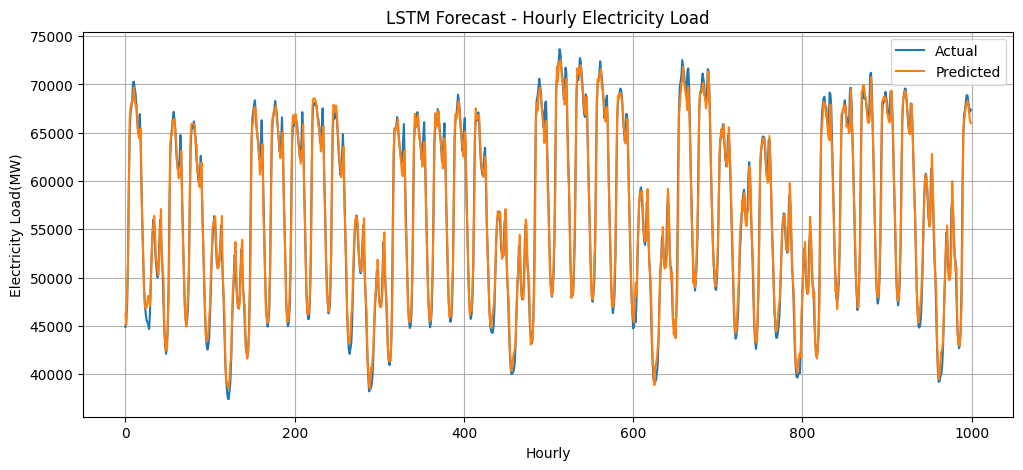

In [50]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_actual[:1000],
    label="Actual"
)

plt.plot(
    y_pred[:1000],
    label="Predicted"
)

plt.title(
    "LSTM Forecast - Hourly Electricity Load"
)

plt.xlabel("Hourly")
plt.ylabel("Electricity Load(MW)")
plt.legend()
plt.grid()
plt.savefig("Figure17-LSTM.png", dpi=300, bbox_inches="tight")
plt.show()